# Tulu Pipeline Results Review

This notebook ingests artifacts from `scripts/run_tulu_pipeline.sh` and summarizes training completion, evaluation coverage, and benchmark comparisons for:

- Centralized Tulu training
- Naive FedAvg on Tulu
- Subspace Bank (bank-per-client)


## 1. Setup and discovery


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')


In [2]:
FS_ROOT = Path.cwd()
if (FS_ROOT / 'FederatedScope').is_dir():
    FS_ROOT = FS_ROOT / 'FederatedScope'

RESULTS_DIR = FS_ROOT / 'results_tulu'
EVAL_DIR = FS_ROOT / 'eval_result'
CKPT_DIR = FS_ROOT / 'ckpts' / 'full'

EXPERIMENTS = {
    'centralized': {
        'label': 'Centralized',
        'ckpt': CKPT_DIR / 'tulu3_federated_centralized.ckpt',
        'save_to': 'ckpts/full/tulu3_federated_centralized.ckpt',
    },
    'fedavg': {
        'label': 'FedAvg',
        'ckpt': CKPT_DIR / 'tulu3_federated_fedavg.ckpt',
        'save_to': 'ckpts/full/tulu3_federated_fedavg.ckpt',
    },
    'bank_perclient': {
        'label': 'Subspace Bank',
        'ckpt': CKPT_DIR / 'tulu3_federated_unlearn_bank_perclient.ckpt',
        'save_to': 'ckpts/full/tulu3_federated_unlearn_bank_perclient.ckpt',
    },
}

BENCHMARKS = ['mmlu', 'gsm8k', 'ifeval', 'humaneval']


In [3]:
from datetime import datetime


def _format_mtime(path):
    if path is None:
        return None
    try:
        ts = path.stat().st_mtime
    except FileNotFoundError:
        return None
    return datetime.fromtimestamp(ts).strftime('%Y-%m-%d %H:%M:%S')


def _candidate_eval_paths(save_to, benchmark):
    save_tag = (save_to or '').replace('/', '_')
    candidates = []
    if benchmark == 'mmlu':
        candidates.append(EVAL_DIR / f'accuracies_{save_tag}.json')
        candidates.append(EVAL_DIR / f'accuracies_{save_tag}__mmlu.json')
    else:
        candidates.append(EVAL_DIR / f'accuracies_{save_tag}__{benchmark}.json')
    # Deduplicate while preserving order
    seen = set()
    unique = []
    for path in candidates:
        if path not in seen:
            unique.append(path)
            seen.add(path)
    return unique


def resolve_eval_result_path(save_to, benchmark):
    candidates = _candidate_eval_paths(save_to, benchmark)
    existing = [path for path in candidates if path.exists()]
    if not existing:
        return None
    return max(existing, key=lambda p: p.stat().st_mtime)


def load_eval_result(save_to, benchmark):
    eval_path = resolve_eval_result_path(save_to, benchmark)
    if eval_path is None:
        return None, None
    with eval_path.open('r', encoding='utf-8') as f:
        return json.load(f), eval_path


def _list_run_dirs(base_dir):
    if not base_dir.exists():
        return []
    return [p for p in base_dir.iterdir() if p.is_dir()]


def _latest_run_dir(base_dir):
    run_dirs = _list_run_dirs(base_dir)
    if not run_dirs:
        return None
    return max(run_dirs, key=lambda p: p.stat().st_mtime)


def summarize_training():
    rows = []
    for exp_key, exp in EXPERIMENTS.items():
        ckpt = exp['ckpt']
        ckpt_exists = (ckpt.exists() if ckpt else True)
        rows.append({
            'experiment': exp_key,
            'label': exp['label'],
            'ckpt_exists': ckpt_exists,
            'ckpt_path': str(ckpt) if ckpt else 'n/a',
            'ckpt_mtime': _format_mtime(ckpt) if ckpt else None,
        })
    return pd.DataFrame(rows)


def summarize_eval_dirs():
    rows = []
    for exp_key in EXPERIMENTS:
        for bench in BENCHMARKS:
            base = RESULTS_DIR / 'global' / exp_key / bench
            run_dirs = _list_run_dirs(base)
            latest_dir = _latest_run_dir(base)
            rows.append({
                'experiment': exp_key,
                'benchmark': bench,
                'eval_runs': len(run_dirs),
                'latest_eval_dir': str(latest_dir) if latest_dir else None,
                'latest_eval_mtime': _format_mtime(latest_dir),
            })
    return pd.DataFrame(rows)


def _extract_metrics(payload, benchmark):
    if payload is None:
        return None, None, {}
    metrics = {
        'weighted_accuracy': payload.get('weighted_accuracy'),
        'strict_accuracy': payload.get('strict_accuracy'),
        'pass@1': payload.get('pass@1'),
        'pass@5': payload.get('pass@5'),
    }
    if benchmark == 'humaneval':
        metric = 'pass@1'
        value = metrics.get('pass@1')
        if value is None:
            metric = 'pass@5'
            value = metrics.get('pass@5')
    elif benchmark == 'ifeval':
        metric = 'weighted_accuracy'
        value = metrics.get('weighted_accuracy')
    else:
        metric = 'weighted_accuracy'
        value = metrics.get('weighted_accuracy')
    return metric, value, metrics


def summarize_eval_results():
    rows = []
    for exp_key, exp in EXPERIMENTS.items():
        save_to = exp['save_to']
        for bench in BENCHMARKS:
            payload, eval_path = load_eval_result(save_to, bench)
            metric, value, metrics = _extract_metrics(payload, bench)
            rows.append({
                'experiment': exp_key,
                'benchmark': bench,
                'metric': metric,
                'primary_value': value,
                'weighted_accuracy': metrics.get('weighted_accuracy'),
                'strict_accuracy': metrics.get('strict_accuracy'),
                'pass@1': metrics.get('pass@1'),
                'pass@5': metrics.get('pass@5'),
                'eval_result_path': str(eval_path) if eval_path else None,
                'eval_result_mtime': _format_mtime(eval_path) if eval_path else None,
            })
    return pd.DataFrame(rows)


## 2. Completion status


In [4]:
training_df = summarize_training()
eval_dirs_df = summarize_eval_dirs()
eval_results_df = summarize_eval_results()

status_df = eval_dirs_df.merge(
    eval_results_df,
    on=['experiment', 'benchmark'],
    how='left',
)

status_df['eval_result_found'] = status_df['eval_result_path'].notna()

print(f"FS_ROOT: {FS_ROOT}")
print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"EVAL_DIR: {EVAL_DIR}")

print("\nTraining checkpoints")
display(training_df)

print("\nEvaluation runs + result artifacts")
display(status_df)

print("\nParsed evaluation metrics")
display(eval_results_df)


FS_ROOT: /storage/ice1/7/0/sbhansali8/FederatedScope
RESULTS_DIR: /storage/ice1/7/0/sbhansali8/FederatedScope/results_tulu
EVAL_DIR: /storage/ice1/7/0/sbhansali8/FederatedScope/eval_result

Training checkpoints


,experiment,label,ckpt_exists,ckpt_path,ckpt_mtime
0,centralized,Centralized,True,/storage/ice1/7/0/sbhansali8/FederatedScope/ck...,2025-12-24 01:08:38
1,fedavg,FedAvg,True,/storage/ice1/7/0/sbhansali8/FederatedScope/ck...,2025-12-24 01:47:17
2,bank_perclient,Subspace Bank,True,/storage/ice1/7/0/sbhansali8/FederatedScope/ck...,2025-12-24 01:51:33



Evaluation runs + result artifacts


,experiment,benchmark,eval_runs,latest_eval_dir,latest_eval_mtime,metric,primary_value,weighted_accuracy,strict_accuracy,pass@1,pass@5,eval_result_path,eval_result_mtime,eval_result_found
0,centralized,mmlu,1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 01:37:14,None,NaN,NaN,None,NaN,NaN,None,None,False
1,centralized,gsm8k,1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 01:37:14,None,NaN,NaN,None,NaN,NaN,None,None,False
2,centralized,ifeval,1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 01:37:15,None,NaN,NaN,None,NaN,NaN,None,None,False
3,centralized,humaneval,1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 01:37:15,pass@1,0.000000,NaN,None,0.000000,0.000000,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 01:38:28,True
4,fedavg,mmlu,4,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 18:12:44,None,NaN,NaN,None,NaN,NaN,None,None,False
5,fedavg,gsm8k,2,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 03:44:52,weighted_accuracy,0.015163,0.015163,None,NaN,NaN,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 05:55:31,True
6,fedavg,ifeval,2,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 03:44:52,None,NaN,NaN,None,NaN,NaN,None,None,False
7,fedavg,humaneval,2,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 03:44:52,pass@1,0.000000,NaN,None,0.000000,0.000000,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 03:55:03,True
8,bank_perclient,mmlu,3,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 18:52:51,None,NaN,NaN,None,NaN,NaN,None,None,False
9,bank_perclient,gsm8k,1,/storage/ice1/7/0/sbhansali8/FederatedScope/re...,2025-12-24 03:58:17,weighted_accuracy,0.018954,0.018954,None,NaN,NaN,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 06:04:32,True



Parsed evaluation metrics


,experiment,benchmark,metric,primary_value,weighted_accuracy,strict_accuracy,pass@1,pass@5,eval_result_path,eval_result_mtime
0,centralized,mmlu,None,NaN,NaN,None,NaN,NaN,None,None
1,centralized,gsm8k,None,NaN,NaN,None,NaN,NaN,None,None
2,centralized,ifeval,None,NaN,NaN,None,NaN,NaN,None,None
3,centralized,humaneval,pass@1,0.000000,NaN,None,0.000000,0.000000,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 01:38:28
4,fedavg,mmlu,None,NaN,NaN,None,NaN,NaN,None,None
5,fedavg,gsm8k,weighted_accuracy,0.015163,0.015163,None,NaN,NaN,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 05:55:31
6,fedavg,ifeval,None,NaN,NaN,None,NaN,NaN,None,None
7,fedavg,humaneval,pass@1,0.000000,NaN,None,0.000000,0.000000,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 03:55:03
8,bank_perclient,mmlu,None,NaN,NaN,None,NaN,NaN,None,None
9,bank_perclient,gsm8k,weighted_accuracy,0.018954,0.018954,None,NaN,NaN,/storage/ice1/7/0/sbhansali8/FederatedScope/ev...,2025-12-24 06:04:32


## 3. Benchmark comparisons


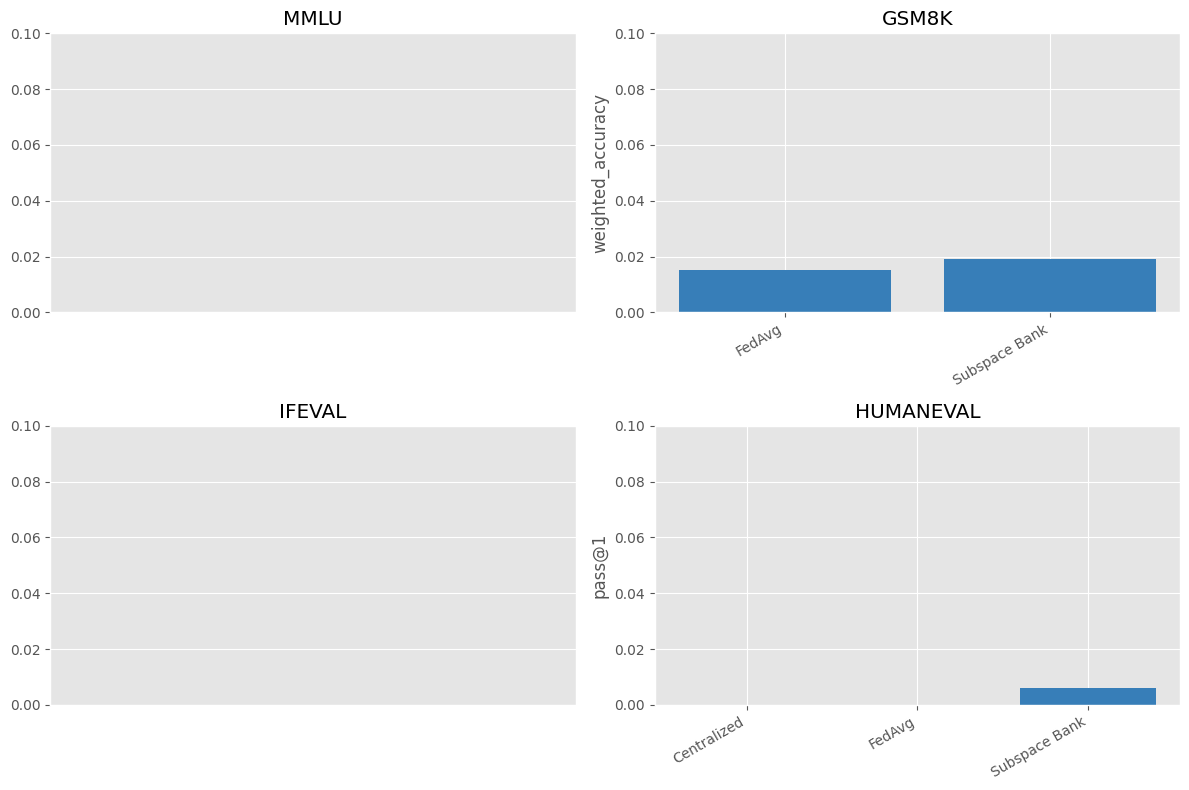

In [8]:
plot_df = eval_results_df.copy()
plot_df['label'] = plot_df['experiment'].map(
    {k: v['label'] for k, v in EXPERIMENTS.items()}
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for idx, bench in enumerate(BENCHMARKS):
    ax = axes[idx]
    bench_df = plot_df[plot_df['benchmark'] == bench]
    bench_df = bench_df.sort_values('label')
    bench_df = bench_df[bench_df['primary_value'].notna()]
    x = np.arange(len(bench_df))
    ax.bar(x, bench_df['primary_value'], color='#377eb8')
    ax.set_title(bench.upper())
    metric_label = bench_df['metric'].iloc[0] if not bench_df.empty else ''
    ax.set_ylabel(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(bench_df['label'], rotation=30, ha='right')
    ax.set_ylim(0, 0.1)

plt.tight_layout()
plt.show()


## 4. Missing evaluations

This table flags experiments/benchmarks with missing evaluation outputs.


In [6]:
missing_df = eval_results_df[eval_results_df['primary_value'].isna()]
missing_df = missing_df[['experiment', 'benchmark', 'eval_result_path']]
display(missing_df)


,experiment,benchmark,eval_result_path
0,centralized,mmlu,None
1,centralized,gsm8k,None
2,centralized,ifeval,None
4,fedavg,mmlu,None
6,fedavg,ifeval,None
8,bank_perclient,mmlu,None
10,bank_perclient,ifeval,None
